# 👩‍💻Engineer and Select Features from Your Dataset

## 📋 Overview
In this hands-on activity, you'll refine your skills in feature engineering and selection, which are pivotal in increasing the performance of machine learning models. By transforming raw data into meaningful features, you'll enhance your ability to represent the underlying problem, thus improving prediction precision. This activity allows you to apply practical feature transformation and selection techniques commonly used in real-world machine learning roles.

## 🎯 Activity Goals
By completing this activity, you will:
- Apply feature transformation techniques to prepare data for machine learning models
- Use dimensionality reduction to streamline features while retaining essential information
- Employ feature selection methods to identify the most predictive attributes in a dataset

## 🌎 Scenario
Imagine you are part of a data analytics team working to improve a predictive model for a client in the [chosen domain based on selected dataset]. Your task is to enhance the model's inputs by engineering and selecting the most relevant features from the dataset, ensuring the model is both performant and efficient.

<b>Reminder:</b> A number of dataset csv files have been uploaded to this lab environment. Choose one dataset from the following options:
- Customer Churn (Telecom): `Telco-Customer-Churn.csv`
- Credit Card Fraud Detection: `creditcard.csv`
- Bike Sharing Demand Forecasting: `bikeshareday.csv`
- IMDb Sentiment Analysis (NLP): `IMDB_Dataset.csv`
- Customer Segmentation (Clustering): `marketing_campaign.csv`

In [1]:
# Load the dataset
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

from scipy.stats import zscore

import warnings 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 10000)

## Step 1: Dataset Exploration
Begin by choosing a dataset from those provided in previous activities. Conduct an exploratory data analysis (EDA) to understand its characteristics, using visualizations to pinpoint patterns and relationships. Identify potential opportunities for feature engineering.

In [2]:
# Your code here
df= pd.read_csv("creditcard.csv")

# Explore the data
print(f"Shape of Data: {df.shape}")
print("\n----- Top 5 Rows of Data ------")
display(df.head())
print("\n----- Information of Data ------")
print(df.info())
print("\n----- Summmary of Data ------")
display(df.describe(percentiles=[i/100 for i in range(0, 101) if i%5==0]).T)
print("\n------- Number of Null Values ---------")
print(df.isnull().sum())

print("Class Count:\n", df['Class'].value_counts(dropna=False))

print("Class distribution:\n", df['Class'].value_counts(dropna=False, normalize=True))

Shape of Data: (284807, 31)

----- Top 5 Rows of Data ------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



----- Information of Data ------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,100%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,0.000000,25297.600000,35027.000000,41216.900000,47694.200000,54201.500000,60776.000000,67232.200000,73261.400000,78622.000000,84692.000000,108574.300000,120396.000000,126528.000000,132929.000000,139320.500000,145247.800000,151328.100000,157640.400000,164143.400000,172792.000000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-56.407510,-2.899147,-1.893272,-1.424545,-1.134663,-0.920373,-0.747294,-0.586700,-0.426756,-0.261842,0.018109,0.570896,1.035107,1.152127,1.224825,1.315642,1.694936,1.924286,2.015409,2.081223,2.454930,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-72.715728,-1.971975,-1.359862,-1.039394,-0.790814,-0.598550,-0.436393,-0.288185,-0.153805,-0.044536,0.065486,0.178647,0.302738,0.459688,0.636845,0.803724,0.957314,1.110220,1.326635,1.808585,22.057729,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-48.325589,-2.389740,-1.802587,-1.483557,-1.169050,-0.890365,-0.616806,-0.397156,-0.199061,0.000025,0.179846,0.331263,0.497040,0.664793,0.843541,1.027196,1.215700,1.417794,1.676173,2.062635,9.382558,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-5.683171,-2.195683,-1.656329,-1.356979,-1.066085,-0.848640,-0.696226,-0.560589,-0.394161,-0.196881,-0.019847,0.142120,0.284856,0.417078,0.558866,0.743341,0.986188,1.213360,1.482807,2.566501,16.875344,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-113.743307,-1.702021,-1.302171,-1.053683,-0.859581,-0.691597,-0.544455,-0.413004,-0.290112,-0.169525,-0.054336,0.064423,0.186625,0.318202,0.457029,0.611926,0.802235,1.042777,1.407893,2.098960,34.801666,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-26.160506,-1.406757,-1.167450,-1.015736,-0.878153,-0.768296,-0.667845,-0.572757,-0.479473,-0.374254,-0.274187,-0.168713,-0.048200,0.077642,0.223245,0.398565,0.628995,0.949038,1.509365,3.160382,73.301626,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-43.557242,-1.434423,-1.078148,-0.846610,-0.683316,-0.554076,-0.426020,-0.286806,-0.159341,-0.051778,0.040103,0.122825,0.213512,0.319154,0.446175,0.570436,0.698332,0.854903,1.039387,1.407632,120.589494,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-73.216718,-0.842147,-0.458945,-0.341845,-0.266300,-0.208630,-0.158158,-0.110961,-0.066057,-0.022503,0.022358,0.069873,0.120489,0.177424,0.243400,0.327346,0.435529,0.578494,0.769381,1.049984,20.007208,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-13.434066,-1.758426,-1.294047,-1.016505,-0.808875,-0.643098,-0.502165,-0.371384,-0.257730,-0.151438,-0.051429,0.054936,0.176169,0.311033,0.445942,0.597139,0.791583,1.020710,1.301671,1.780783,15.594995,15.594995



------- Number of Null Values ---------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class Count:
 Class
0    284315
1       492
Name: count, dtype: int64
Class distribution:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


<b>💡 Tip:</b> Use libraries like Matplotlib or Seaborn for creating insightful data visualizations.

<b>❗ Common Mistakes</b>
- Overlooking skewed data distributions
- Failing to explore correlations adequately

## Step 2: Feature Transformation
Select at least two features that may benefit from transformations such as logarithmic, square root, or polynomial changes. Implement these transformations with Python libraries like NumPy or Pandas, and visualize how they've impacted data distributions.

In [3]:
# Your code here

df['_log_amount'] = np.log1p(df['Amount'])

<b>💡 Tip:</b> Pay close attention to how transformations alter skewness and improve normality.

<b>❗ Common Mistakes</b>
- Applying inappropriate transformations
- Ignoring the effect of transformation on model interpretability

## Step 3: Dimensionality Reduction
For datasets with many features, apply a dimensionality reduction technique such as PCA (Principal Component Analysis). Examine the variance explained by each component to ensure the most informative features are retained.

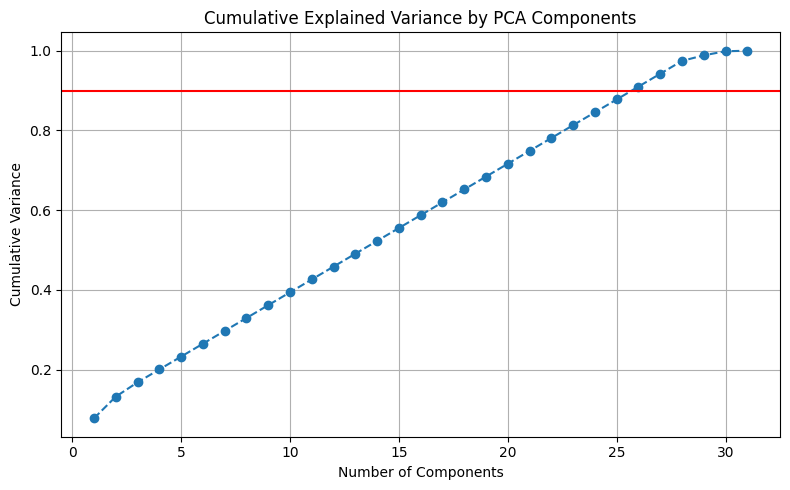

✅ Retain 26 components to preserve ≥90% variance


In [8]:
# Your code here

# Step 1: Select numeric features (excluding target)
features = df.drop(columns=['Class'])  # adjust if your target column is named differently
numeric_cols = features.select_dtypes(include=np.number).columns

# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Step 3: Apply PCA
pca = PCA()
pca_components = pca.fit_transform(scaled_data)

# Step 4: Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Step 5: Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: Choose number of components to retain 90% variance
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"✅ Retain {n_components_90} components to preserve ≥90% variance")

<b>💡 Tip:</b> Retain enough components to preserve at least 90% of the data's variance.

<b>❗ Common Mistakes</b>
- Over-reducing features, leading to loss of important information
- Not properly interpreting PCA results

In [10]:
# Your code here
pca_final = PCA(n_components=n_components_90)
reduced_data = pca_final.fit_transform(scaled_data)
# reduced_data

## Step 4: Feature Selection
Employ a feature selection method, like Recursive Feature Elimination (RFE), to pinpoint and retain the top features for your predictive task. Assess the chosen features for their contribution to the model's effectiveness.

In [11]:
# Your code here

# Step 1: Prepare data
X = df.drop(columns=['Class'])  # Features
y = df['Class']                 # Target

# Optional: scale features for models sensitive to magnitude
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Choose base model
model = LogisticRegression(max_iter=1000)

# Step 3: Apply RFE
rfe = RFE(estimator=model, n_features_to_select=10)  # You can tune this number
rfe.fit(X_scaled, y)

# Step 4: Get selected features
selected_features = X.columns[rfe.support_]
print("Selected Features via RFE:")
print(selected_features)

# Step 5: Evaluate model performance using selected features
X_selected = X_scaled[:, rfe.support_]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
score = model.score(X_test, y_test)
cv_score = cross_val_score(model, X_selected, y, cv=5, scoring='accuracy')

print(f"\nTest Accuracy: {score:.4f}")
print(f"Cross-Validated Accuracy: {cv_score.mean():.4f} ± {cv_score.std():.4f}")


Selected Features via RFE:
Index(['V4', 'V8', 'V9', 'V10', 'V13', 'V14', 'V16', 'V21', 'V22', 'V27'], dtype='object')

Test Accuracy: 0.9991
Cross-Validated Accuracy: 0.9992 ± 0.0001


<b>💡 Tip:</b> Pair feature selection with model evaluation metrics to validate effectiveness.

<b>❗ Common Mistakes</b>
- Choosing too few or too many features
- Not cross-validating feature selection results

## Step 5: Reflection and Summary
Compile a brief report summarizing your choices in feature engineering. Articulate the reasoning behind each transformation or selection decision, and predict how these will enhance your model's predictions.

In [ ]:
# Your code here

## ✅ Success Checklist
- Thorough EDA conducted with meaningful insights
- Effective transformation of key features
- Appropriate use of dimensionality reduction techniques
- Accurate identification of relevant features
- Clear rationale for feature engineering decisions

## 💡 Key Points
- Effective feature engineering can drastically enhance model performance.
- Dimensionality reduction helps maintain model efficiency without sacrificing accuracy.
- Strategic feature selection can lead to simpler, yet powerful models.

## 📚 Exemplar Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
 # Step 1: Load and Clean Data
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Preview
print(df.head())
print(df.info())

# Convert TotalCharges to numeric and drop missing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop ID column
df.drop(columns=['customerID'], inplace=True)

"""# Step 2: Feature Transformation"""

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Transform skewed columns
df['log_TotalCharges'] = np.log1p(df['TotalCharges'])
df['sqrt_tenure'] = np.sqrt(df['tenure'])

# Show before/after plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['TotalCharges'], kde=True, ax=axes[0]).set_title('Original TotalCharges')
sns.histplot(df['log_TotalCharges'], kde=True, ax=axes[1]).set_title('Log‑transformed')

plt.tight_layout()

print("Skew (TotalCharges):", skew(df['TotalCharges']))
print("Skew (log_TotalCharges):", skew(df['log_TotalCharges']))

"""# Step 3: Encode, Scale, & Apply PCA"""

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Encode target
df['ChurnEnc'] = LabelEncoder().fit_transform(df['Churn'])

# Identify categorical features
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]
multi_cat = [col for col in df.select_dtypes(include='object').columns if col not in binary_cols + ['Churn']]

# Label-encode binary, one-hot encode others
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cat, drop_first=True)

# Scale continuous features for PCA
feature_pca = ['MonthlyCharges', 'log_TotalCharges', 'sqrt_tenure']
scaler = StandardScaler()
X_pca = scaler.fit_transform(df[feature_pca])

# PCA
pca = PCA(n_components=None)
pca.fit(X_pca)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel('n components')
plt.ylabel('cumulative explained variance')
plt.title('PCA Explained Variance')
plt.show()

"""# Step 4: Feature Selection with RFE"""

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Define feature matrix and target
y = df['ChurnEnc']
X = df.drop(columns=['Churn', 'ChurnEnc'])

# Standardize features
X_scaled = scaler.fit_transform(X)

# RFE
model = LogisticRegression(max_iter=1000)
selector = RFE(model, n_features_to_select=10)
selector.fit(X_scaled, y)

# Print selected features
selected = X.columns[selector.support_]
print("RFE-selected features:", list(selected))

"""# Step 5: Reflection & Summary"""

print("SUMMARY")
print("– Transformations reduced skew for TotalCharges and tenure.")
print("– PCA components captured ≥90% variance from key billing features.")
print(f"– RFE selected top predictors of churn: {list(selected)}")
print("These engineered and selected features can streamline modeling efforts while preserving predictive power.")
```    

### How does your work compare?
- Did your transformed features meet the expected improvements?
- Are your selected features logically aligned with the task requirements?

## 🚀 Next Steps
Reflect on the impact of feature engineering on your machine learning models and explore how these techniques can be applied to diverse datasets and domains in subsequent activities focused on model building and evaluation.